<a href="https://colab.research.google.com/github/kniksiyassir/cc1-neural-networks/blob/main/iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CC1 — Partie 1 : Classification, Dataset Iris
Comparaison de MLPClassifier (Scikit-learn) et d’un réseau de neurones TensorFlow/Keras

Réalisé par : KNIKSI YASSIR

Consigne : Exécuter les cellules dans l’ordre (Exécution → Tout exécuter).

In [15]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("iris.csv")

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes\n")
display(df.head(10))                    # aperçu du tableau
display(df.describe().round(2))         # statistiques
display(df["variety"].value_counts().to_frame("Nombre"))   # répartition des classes

Dimensions : 150 lignes x 5 colonnes



,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


,sepal.length,sepal.width,petal.length,petal.width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


,Nombre
variety,
Setosa,50
Versicolor,50
Virginica,50


In [ ]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("iris.csv")
print("Dimensions :", df.shape)
display(df.head(10))
df.info()

Dimensions : (150, 5)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Imports et préparation des données

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

SEED, EPOCHS = 42, 200
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

df = pd.read_csv("iris.csv")
le = LabelEncoder()
X = df.drop(columns="variety").values.astype("float32")
y = le.fit_transform(df["variety"])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
sc = StandardScaler().fit(Xtr)
Xtr, Xte = sc.transform(Xtr).astype("float32"), sc.transform(Xte).astype("float32")
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [13]:
def curves(loss, vloss, acc, vacc, title, final_acc, color):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    ax[0].plot(acc, label="Train", color=color)
    ax[0].plot(vacc, label="Test", color="gray", ls="--")
    ax[0].set(title=f"{title} : Accuracy (finale test = {final_acc:.2%})", xlabel="Epoch", ylabel="Accuracy")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(loss, label="Train", color=color)
    ax[1].plot(vloss, label="Test", color="gray", ls="--")
    ax[1].set(title=f"{title} : Loss", xlabel="Epoch", ylabel="Loss")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 1.1 Scikit-learn : MLPClassifier

Accuracy MLPClassifier : 0.9667


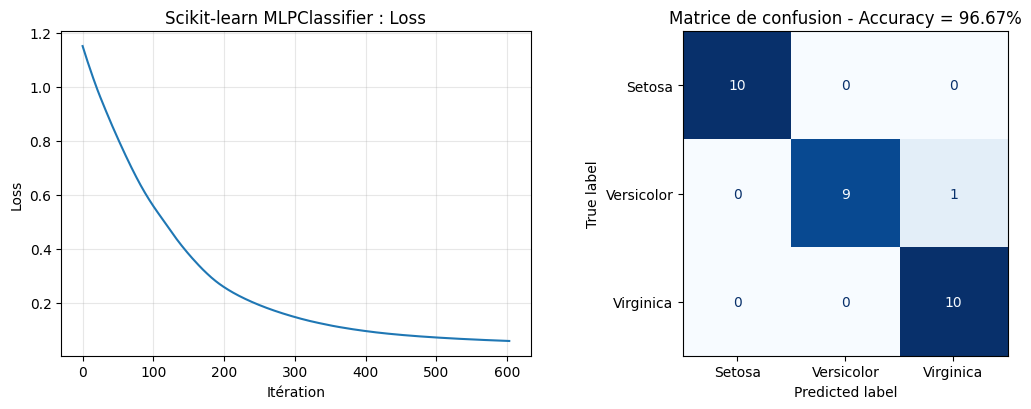

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=SEED).fit(Xtr, ytr)
acc_sk = accuracy_score(yte, mlp.predict(Xte))
print(f"Accuracy MLPClassifier : {acc_sk:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(mlp.loss_curve_, color="#1f77b4")
ax[0].set(title="Scikit-learn MLPClassifier : Loss", xlabel="Itération", ylabel="Loss")
ax[0].grid(alpha=.3)
ConfusionMatrixDisplay.from_predictions(yte, mlp.predict(Xte), display_labels=le.classes_,
                                        ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title(f"Matrice de confusion - Accuracy = {acc_sk:.2%}")
plt.tight_layout(); plt.show()

## 1.2 TensorFlow / Keras

Accuracy Keras : 0.9667


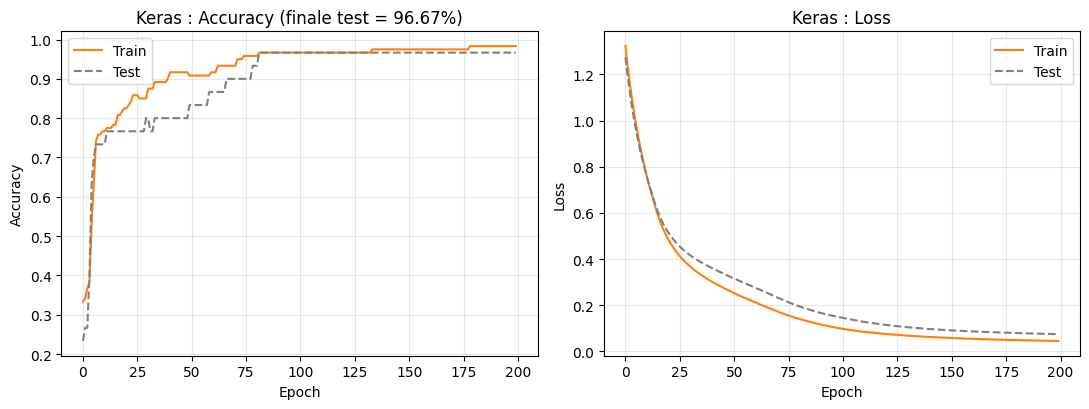

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=EPOCHS, batch_size=16, verbose=0).history
acc_keras = model.evaluate(Xte, yte, verbose=0)[1]
print(f"Accuracy Keras : {acc_keras:.4f}")
curves(h["loss"], h["val_loss"], h["accuracy"], h["val_accuracy"], "Keras", acc_keras, "#ff7f0e")

## TensorFlow bas niveau (GradientTape)

Accuracy TensorFlow : 0.9333


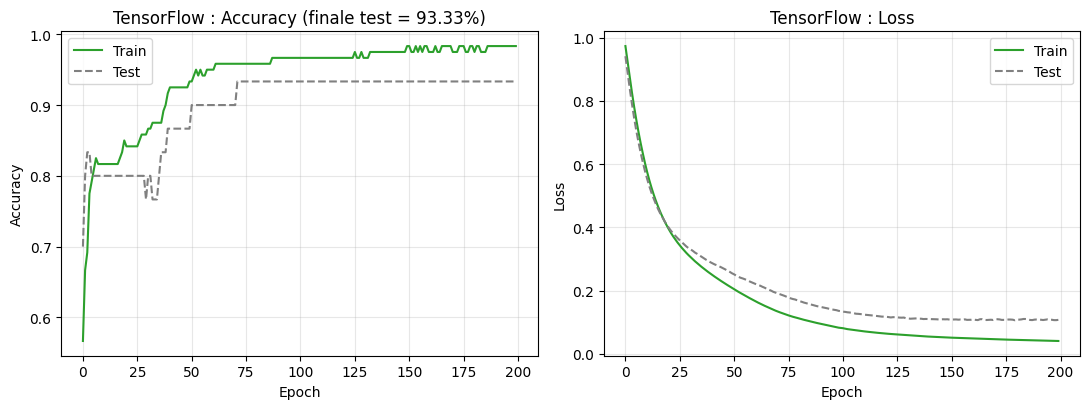

In [ ]:
init = tf.keras.initializers.GlorotUniform(seed=SEED)
W1, b1 = tf.Variable(init((4, 10))),  tf.Variable(tf.zeros(10))
W2, b2 = tf.Variable(init((10, 10))), tf.Variable(tf.zeros(10))
W3, b3 = tf.Variable(init((10, 3))),  tf.Variable(tf.zeros(3))
params = [W1, b1, W2, b2, W3, b3]

def forward(x):
    x = tf.nn.relu(tf.matmul(x, W1) + b1)
    x = tf.nn.relu(tf.matmul(x, W2) + b2)
    return tf.matmul(x, W3) + b3

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
opt = tf.keras.optimizers.Adam(0.001)
acc_of = lambda x, y: float(np.mean(np.argmax(forward(x).numpy(), 1) == y))

H = {"loss": [], "vloss": [], "acc": [], "vacc": []}
ds = tf.data.Dataset.from_tensor_slices((Xtr, ytr)).shuffle(len(Xtr), seed=SEED).batch(16)
for _ in range(EPOCHS):
    for xb, yb in ds:
        with tf.GradientTape() as tape:
            l = loss_fn(yb, forward(xb))
        opt.apply_gradients(zip(tape.gradient(l, params), params))
    H["loss"].append(float(loss_fn(ytr, forward(Xtr))))
    H["vloss"].append(float(loss_fn(yte, forward(Xte))))
    H["acc"].append(acc_of(Xtr, ytr))
    H["vacc"].append(acc_of(Xte, yte))
acc_tf = acc_of(Xte, yte)
print(f"Accuracy TensorFlow : {acc_tf:.4f}")
curves(H["loss"], H["vloss"], H["acc"], H["vacc"], "TensorFlow", acc_tf, "#2ca02c")

## 1.3 Comparaison et 1.4 Visualisation

                      Modèle  Accuracy
MLPClassifier (scikit-learn)  0.966667
                       Keras  0.966667
   TensorFlow (GradientTape)  0.933333


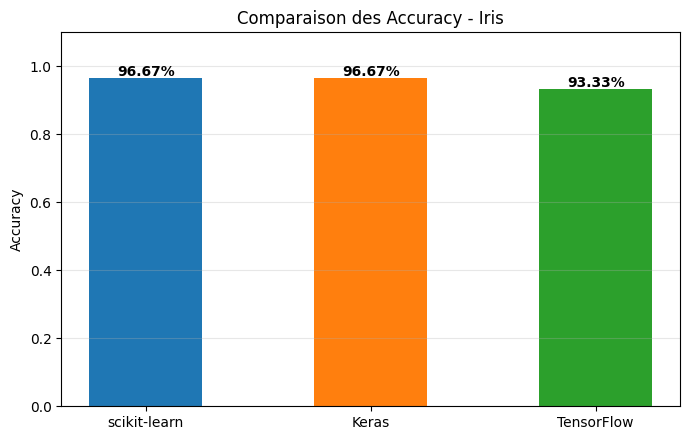

In [ ]:
res = pd.DataFrame({"Modèle": ["MLPClassifier (scikit-learn)", "Keras", "TensorFlow (GradientTape)"],
                    "Accuracy": [acc_sk, acc_keras, acc_tf]})
print(res.to_string(index=False))

plt.figure(figsize=(7, 4.5))
bars = plt.bar(["scikit-learn", "Keras", "TensorFlow"], res["Accuracy"],
               color=["#1f77b4", "#ff7f0e", "#2ca02c"], width=0.5)
for b, a in zip(bars, res["Accuracy"]):
    plt.text(b.get_x() + b.get_width()/2, a + 0.005, f"{a:.2%}", ha="center", fontweight="bold")
plt.ylim(0, 1.1); plt.ylabel("Accuracy")
plt.title("Comparaison des Accuracy - Iris"); plt.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()